<a href="https://colab.research.google.com/github/goitstudent123/numerical_programming_python/blob/main/%D0%94%D0%979_%D0%93%D0%90%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!wget -O SpamEmailClassificationDataset.zip "https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/SpamEmailClassificationDataset.zip?raw=true"
!unzip -o SpamEmailClassificationDataset.zip


--2025-11-02 12:34:26--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/SpamEmailClassificationDataset.zip?raw=true
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/SpamEmailClassificationDataset.zip [following]
--2025-11-02 12:34:27--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/SpamEmailClassificationDataset.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/SpamEmailClassificationDataset.zip [following]
--2025-11-02 12:34:27--  https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/SpamEmailClassificationDataset.zip
Res

Counts after cleaning:
label
1    7813
0    7047
Name: count, dtype: int64

Balanced sample size: 5000
label
0    2500
1    2500
Name: count, dtype: int64


/tmp/ipython-input-2997187875.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=per_class_target, random_state=42))


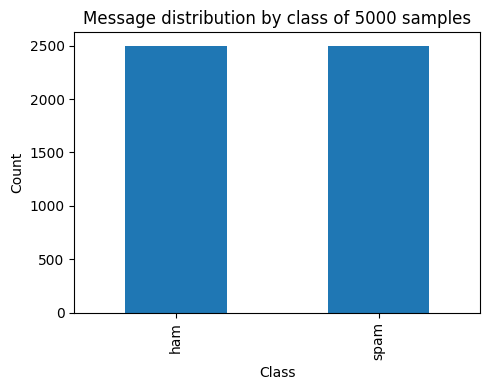

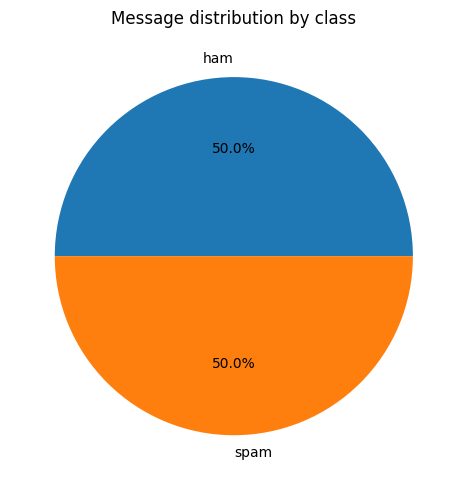

In [15]:
import pandas as pd
df = pd.read_csv("SpamEmailClassificationDataset/combined_data.csv")

df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print("Counts after cleaning:")
print(df['label'].value_counts())

DESIRED_TOTAL = 5000

counts = df['label'].value_counts()
min_per_class = counts.min()
per_class_target = min(min_per_class, DESIRED_TOTAL // 2)

if per_class_target == 0:
    raise ValueError("Not enough data to create a balanced sample.")

balanced_df = (
    df.groupby('label', group_keys=False)
      .apply(lambda g: g.sample(n=per_class_target, random_state=42))
      .reset_index(drop=True)
)

print("\nBalanced sample size:", len(balanced_df))
print(balanced_df['label'].value_counts())

label_map = {0: "ham", 1: "spam"}
balanced_df['label_name'] = balanced_df['label'].map(label_map)

plt.figure(figsize=(5,4))
balanced_df['label_name'].value_counts().plot(kind='bar')
plt.title(f"Message distribution by class of {DESIRED_TOTAL} samples")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(5,5))
balanced_df['label_name'].value_counts().plot(kind='pie', autopct='%1.1f%%', ylabel="")
plt.title("Message distribution by class")
plt.tight_layout()
plt.show()


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import nltk
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
from nltk.stem import WordNetLemmatizer
corpus = []
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

for document in df["text"]:
    document = re.sub("[^a-zA-Z]", " ", document).lower()
    document = document.split()
    document = [lemmatizer.lemmatize(word) for word in document if word not in stop_words]
    # print(document)
    document = list(set(document))
    document = " ".join(document)
    corpus.append(document)

df["text"] = corpus

In [19]:
import numpy as np

# split spam/ham
spam_df = df[df["label"] == 1]
ham_df  = df[df["label"] == 0]

train_spam = spam_df["text"].tolist()
train_ham  = ham_df["text"].tolist()

# create test dict from full dataset (random sample 200)
test_sample = df.sample(200, random_state=42)
test_emails = dict(zip(test_sample.index, test_sample["text"]))

len(train_spam), len(train_ham), len(test_emails)

(7813, 7047, 200)

In [21]:
from collections import Counter, defaultdict
import math

# count words for spam and ham
spam_words = Counter(" ".join(train_spam).split())
ham_words  = Counter(" ".join(train_ham).split())

# total words
total_spam_words = sum(spam_words.values())
total_ham_words = sum(ham_words.values())

# vocabulary
all_words = set(spam_words.keys()).union(set(ham_words.keys()))
V = len(all_words)

# class priors
p_spam = len(train_spam) / (len(train_spam) + len(train_ham))
p_ham  = len(train_ham) / (len(train_spam) + len(train_ham))

def predict(email: str):
    words = email.split()

    spam_log = math.log(p_spam)
    ham_log  = math.log(p_ham)

    for w in words:
        # Laplace smoothing
        spam_log += math.log((spam_words[w] + 1) / (total_spam_words + V))
        ham_log  += math.log((ham_words[w] + 1) / (total_ham_words + V))

    return "spam" if spam_log > ham_log else "ham"



In [23]:
spam_word_prob = {w: (spam_words[w] + 1) / (total_spam_words + V) for w in spam_words}
# sort desc
top_spam_words = sorted(spam_word_prob.items(), key=lambda x: x[1], reverse=True)[:40]
top_spam_words[:20]

for w, p in top_spam_words[:20]:
    print(w, round(p, 6))

escapenumber 0.005107
http 0.004049
com 0.00301
price 0.002644
u 0.002639
one 0.002585
time 0.00234
day 0.002225
get 0.002089
escapelong 0.001932
please 0.001846
like 0.001777
see 0.001777
new 0.001773
offer 0.001743
e 0.001685
product 0.001657
may 0.001654
best 0.001642
money 0.00156


# Analysis
Naive Bayes model extracted the words with the highest conditional probability of appearing in spam.
The top spam-associated terms clearly indicate typical spam behavior patterns.

Most characteristic spam words:
* URL markers: http, com
* commercial trigger words: price, offer, product, best, money, get
* persuasive softening / social hooks: please, new, like, see, day

Additionally there some technical artifacts (escapenumber, escapelong, u, e) which came from URL escapes and encoding side effects — this is normal and can be cleaned with a more explicit regex pre-processing step.

# Interpretation:

Spam messages in this dataset are strongly associated with:

- Links (redirects outside the platform)
- Promises/offers of money or products
- Marketing “pitch language” designed to trigger attention

# Evaluation:

The classifier captured the real semantic nature of spam fairly well.